In [1]:
import pandas as pd

df = pd.read_csv('data/creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [3]:
fraud_percentage = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"Fraud transactions: {fraud_percentage:.3f}% of all transactions")

Fraud transactions: 0.173% of all transactions


In [4]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


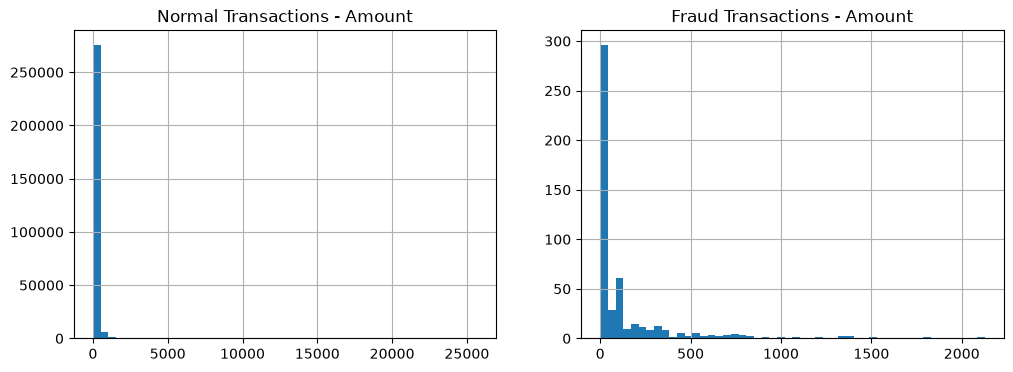

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[0])
axes[0].set_title('Normal Transactions - Amount')

df[df['Class']==1]['Amount'].hist(bins=50, ax=axes[1])
axes[1].set_title('Fraud Transactions - Amount')

plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# X = all the features, y = the target we're predicting (fraud or not)
X = df.drop('Class', axis=1)
y = df['Class']

# Split into training data (80%) and testing data (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (227845, 30)
Test set size: (56962, 30)


In [7]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # helps with imbalance
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [8]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability scores, not just yes/no

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Confusion Matrix:
[[56781    83]
 [   15    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.50      0.85      0.63        98

    accuracy                           1.00     56962
   macro avg       0.75      0.92      0.81     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9733713916770985


In [10]:
import joblib

joblib.dump(model, 'fraud_model.pkl')
print("Model saved!")

Model saved!


In [11]:
from sklearn.metrics import precision_score, recall_score

for threshold in [0.3, 0.5, 0.7, 0.9]:
    y_pred_adjusted = (y_pred_proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_adjusted)
    recall = recall_score(y_test, y_pred_adjusted)
    print(f"Threshold {threshold}: Precision={precision:.3f}, Recall={recall:.3f}")

Threshold 0.3: Precision=0.360, Recall=0.867
Threshold 0.5: Precision=0.500, Recall=0.847
Threshold 0.7: Precision=0.669, Recall=0.847
Threshold 0.9: Precision=0.810, Recall=0.827


In [12]:
import json

sample = X_test.iloc[0].to_dict()
print(json.dumps(sample, indent=2))

{
  "Time": 160760.0,
  "V1": -0.674466064578314,
  "V2": 1.40810501967799,
  "V3": -1.11062205357093,
  "V4": -1.32836577843066,
  "V5": 1.38899603254837,
  "V6": -1.30843906707795,
  "V7": 1.88587890268717,
  "V8": -0.614232966299775,
  "V9": 0.311652212453101,
  "V10": 0.65075700363522,
  "V11": -0.857784661547805,
  "V12": -0.229961445775592,
  "V13": -0.19981700479103,
  "V14": 0.266371326329879,
  "V15": -0.0465441684754424,
  "V16": -0.741398089749789,
  "V17": -0.605616644106022,
  "V18": -0.39256818789208,
  "V19": -0.162648311024695,
  "V20": 0.394321820843914,
  "V21": 0.0800842396026648,
  "V22": 0.810033595602455,
  "V23": -0.224327230436412,
  "V24": 0.707899237446867,
  "V25": -0.13583702273753,
  "V26": 0.0451021964988772,
  "V27": 0.533837219064273,
  "V28": 0.291319252625364,
  "Amount": 23.0
}


In [13]:
# Find an actual fraud transaction in the test set
fraud_sample = X_test[y_test == 1].iloc[0].to_dict()
print(json.dumps(fraud_sample, indent=2))

{
  "Time": 57007.0,
  "V1": -1.27124419171437,
  "V2": 2.46267526851135,
  "V3": -2.85139500331783,
  "V4": 2.3244800653478,
  "V5": -1.37224488981369,
  "V6": -0.948195686538643,
  "V7": -3.06523436172054,
  "V8": 1.16692694787211,
  "V9": -2.26877058844813,
  "V10": -4.88114292689057,
  "V11": 2.25514748870463,
  "V12": -4.68638689759229,
  "V13": 0.652374668512965,
  "V14": -6.17428834800643,
  "V15": 0.594379608016446,
  "V16": -4.84969238709652,
  "V17": -6.53652073527011,
  "V18": -3.11909388163881,
  "V19": 1.71549441975915,
  "V20": 0.560478075726644,
  "V21": 0.652941051330455,
  "V22": 0.0819309763507574,
  "V23": -0.221347831198339,
  "V24": -0.523582159233306,
  "V25": 0.224228161862968,
  "V26": 0.756334522703558,
  "V27": 0.632800477330469,
  "V28": 0.250187092757197,
  "Amount": 0.01
}


In [14]:
import pandas as pd

df = pd.read_csv('data/creditcard.csv')

# Create a small demo sample: 180 normal + 20 fraud transactions
normal_sample = df[df['Class'] == 0].sample(180, random_state=42)
fraud_sample = df[df['Class'] == 1].sample(20, random_state=42)
demo_sample = pd.concat([normal_sample, fraud_sample]).sample(frac=1, random_state=1)

demo_sample.to_csv('data/demo_sample.csv', index=False)
print("Sample saved!")

Sample saved!
